**HOUSE PRICE PREDICTION**

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [8]:
#Loading the dataset
data = pd.read_csv('/content/House Price Prediction Dataset.csv')

In [9]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [10]:
data.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [13]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [14]:
data.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [15]:
data.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [ ]:
# Scaling Numeric Features


StandardScaler applied to numeric columns (Area, Bedrooms, Bathrooms, Floors,YearBuilt, Price)

In [16]:
numeric_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [18]:
# Encoding Categorical Features
categorical_cols = ['Location', 'Condition', 'Garage']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

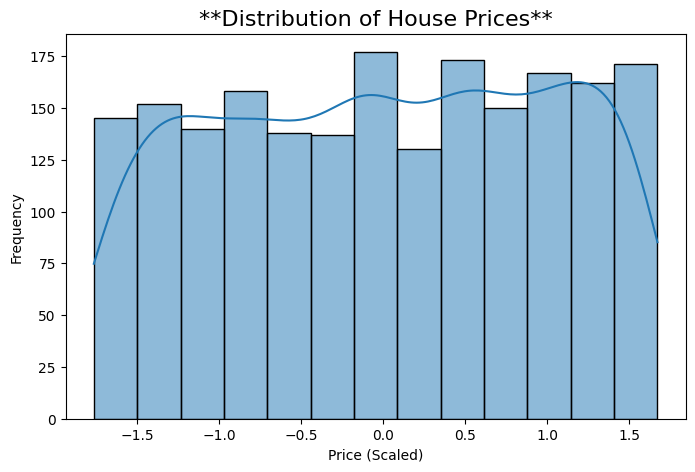

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Price'], kde=True)
plt.title('**Distribution of House Prices**', fontsize=16)
plt.xlabel('Price (Scaled)')
plt.ylabel('Frequency')
plt.show()

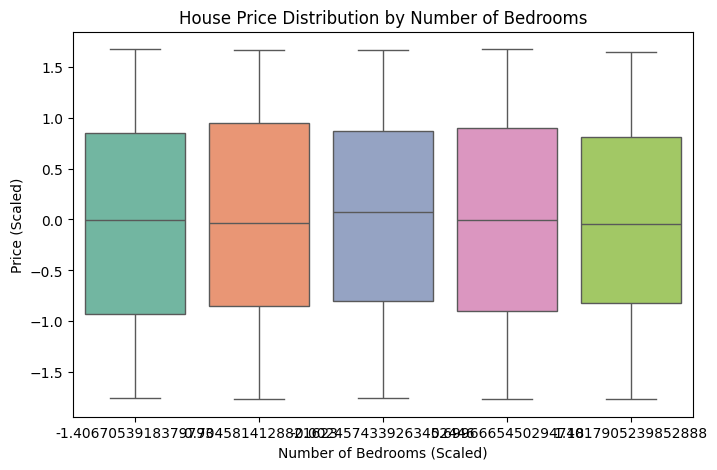

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Bedrooms', y='Price', data=data, palette='Set2')
plt.title('House Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms (Scaled)')
plt.ylabel('Price (Scaled)')
plt.show()

 Linear Regression Model — House Price Prediction

In [21]:
from sklearn.ensemble import RandomForestRegressor
# Select features and target
X = data[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']]
y = data['Price']

In [22]:
# Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### Actual vs. Predicted Prices and House Area vs. Prices

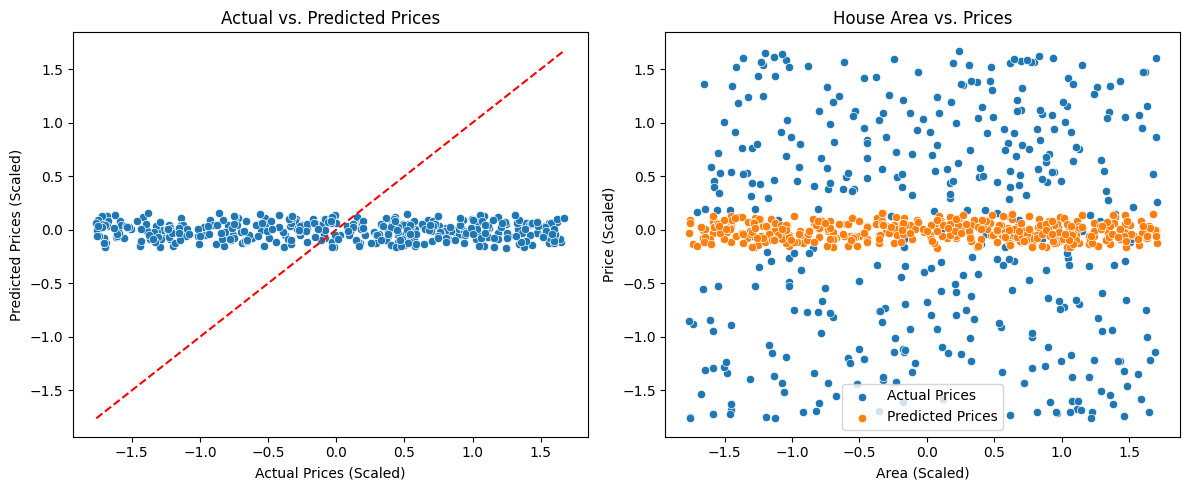

In [24]:
plt.figure(figsize=(12, 5))

# Scatter Plot 1: Actual vs. Predicted Prices
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Diagonal reference line
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Prices (Scaled)')
plt.ylabel('Predicted Prices (Scaled)')

# Scatter Plot 2: House Area vs. Actual and Predicted Prices
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x=X_test['Area'], y=y_test, label='Actual Prices')
sns.scatterplot(x=X_test['Area'], y=y_pred, label='Predicted Prices')
plt.title('House Area vs. Prices')
plt.xlabel('Area (Scaled)')
plt.ylabel('Price (Scaled)')
plt.legend()

plt.tight_layout()
plt.show()